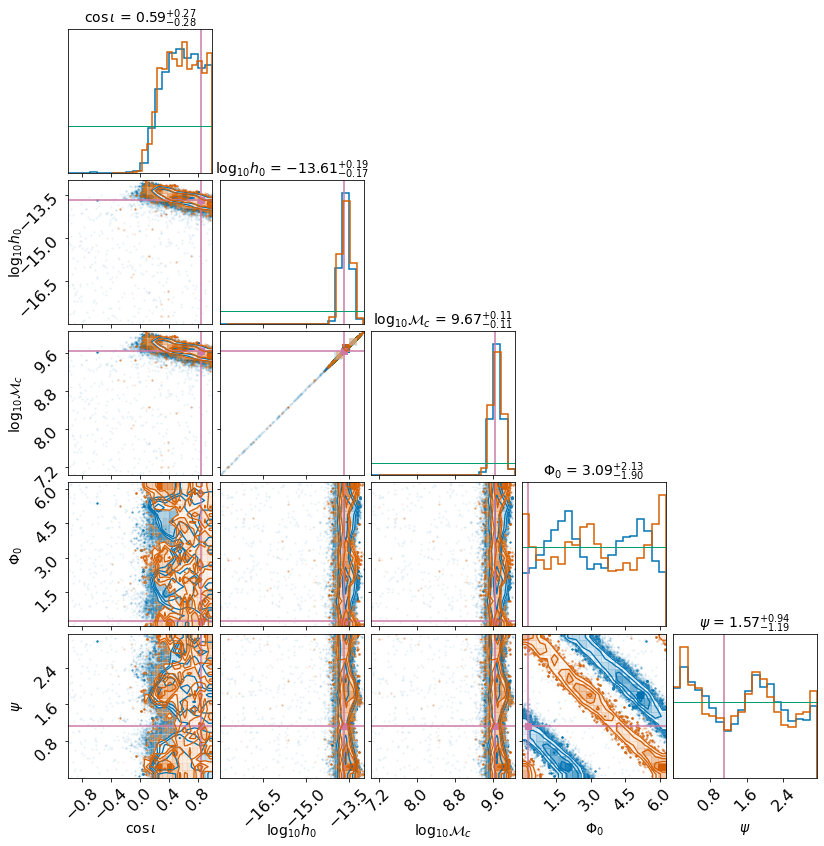

In [4]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import h5py
import matplotlib.pyplot as plt
import corner

# ============================================================
# 1. Truth values (QuickCW naming)
# ============================================================
truth = {
    "0_cos_inc":   0.8412486994612669,
    "0_log10_mc":  np.log10(4.3e9),
    "0_log10_h":   -13.668773493298787,
    "0_psi":       1.1187560505283651,
    "0_phase0":    0.24434609527920614,
}

# ------------------------------------------------------------
# ORDER: cos i, h, Mc, phase0, psi
# ------------------------------------------------------------
qc_keys = ["0_cos_inc", "0_log10_h", "0_log10_mc", "0_phase0", "0_psi"]

labels = [
    r"$\cos\iota$",
    r"$\log_{10} h_0$",
    r"$\log_{10}\mathcal{M}_c$",
    r"$\Phi_0$",
    r"$\psi$",
]

# ============================================================
# 2. Priors (green)
# ============================================================
def add_priors(ax, i):
    if i == 0:  # cos i
        X = np.linspace(-1, 1)
        ax.plot(X, 0*X + 0.5, color="#009E73", lw=1)

    elif i == 1:  # log10 h
        xl, xr = ax.get_xlim()
        X = np.linspace(xl, xr)
        ax.plot(X, 0*X + 1/(xr-xl), color="#009E73", lw=1)

    elif i == 2:  # log10 Mc
        xl, xr = ax.get_xlim()
        X = np.linspace(xl, xr)
        ax.plot(X, 0*X + 1/(xr-xl), color="#009E73", lw=1)

    elif i == 3:  # phase0
        X = np.linspace(0, 2*np.pi)
        ax.plot(X, 0*X + 1/(2*np.pi), color="#009E73", lw=1)

    elif i == 4:  # psi
        X = np.linspace(0, np.pi)
        ax.plot(X, 0*X + 1/np.pi, color="#009E73", lw=1)


# ============================================================
# 3. Load QuickCW
# ============================================================
quickcw_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_narrow_detect_dLmasked_75.400Mpc.h5"
)

with h5py.File(quickcw_file, "r") as f:
    qc_samples = f["samples_masked"][...]
    qc_params  = [x.decode("utf-8") for x in f["par_names"][...]]

qc_plot = np.column_stack([
    qc_samples[:, qc_params.index(k)] for k in qc_keys
])

# ============================================================
# 4. Load Enterprise
# ============================================================
enterprise_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "core_single_MDC2.h5"
)

with h5py.File(enterprise_file, "r") as f:
    e_samples = f["chain"][...]
    e_params  = [p.decode("utf-8") for p in f["params"][...]]
    burn      = f["metadata/burn"][()]

e_samples = e_samples[burn:, :]

idx_cos_inc  = e_params.index("cos_inc")
idx_log10_mc = e_params.index("log10_mc")
idx_phase0   = e_params.index("phase0")
idx_psi      = e_params.index("psi")

cos_inc_ent  = e_samples[:, idx_cos_inc]
log10_mc_ent = e_samples[:, idx_log10_mc]
phase0_ent   = e_samples[:, idx_phase0]
psi_ent      = e_samples[:, idx_psi]

# ============================================================
# 5. ENTERPRISE → PHYSICAL h0 (CRITICAL FIX)
# ============================================================
f = 3.7e-9  # Hz

# Distance
D_MPC = 75.400
MPC2M = 3.085677581491367e22
dL_m = D_MPC * MPC2M

# Constants
G = 6.67430e-11
c = 2.99792458e8
M_sun = 1.98840987e30

# Chirp mass in time units (seconds)
mc_solar = 10**log10_mc_ent
mc_time  = mc_solar * M_sun * G / c**3

# Distance in time units (seconds)  <<< THIS IS THE FIX
dL_time = dL_m / c

# Dimensionless strain h0
h0_ent = (
    2
    * mc_time**(5/3)
    * (np.pi * f)**(2/3)
    / dL_time
)

log10_h0_ent = np.log10(h0_ent)

# ------------------------------------------------------------
# ORDER: cos i, h, Mc, phase0, psi
# ------------------------------------------------------------
ent_plot = np.column_stack([
    cos_inc_ent,
    log10_h0_ent,
    log10_mc_ent,
    phase0_ent,
    psi_ent,
])

# ============================================================
# 6. Plot styling
# ============================================================
plt.rcParams["font.size"] = 16

c_qc    = "#0072B2"
c_ent   = "#D55E00"
c_truth = "#CC79A7"

# ============================================================
# 7. Plot QuickCW
# ============================================================
fig = corner.corner(
    qc_plot,
    labels=labels,
    truths=[truth[k] for k in qc_keys],
    truth_color=c_truth,
    color=c_qc,
    show_titles=True,
    hist_kwargs=dict(density=True, linewidth=1.5),
    contour_kwargs=dict(linewidths=1.3),
    fill_contours=False,
)

# ============================================================
# 8. Overlay Enterprise
# ============================================================
corner.corner(
    ent_plot,
    fig=fig,
    color=c_ent,
    show_titles=False,
    hist_kwargs=dict(density=True, linewidth=1.5),
    contour_kwargs=dict(linewidths=1.3),
    fill_contours=False,
)

# ============================================================
# 9. Priors
# ============================================================
axes = np.array(fig.axes).reshape(len(labels), len(labels))
for i in range(len(labels)):
    add_priors(axes[i, i], i)

plt.show()


In [6]:
from enterprise_extensions import model_utils
# amplitude column in qc_plot = column index 3 if you included fgw
# but in your 5-parameter version, log10_h was index=2
qc_amp = qc_plot[:, qc_keys.index("0_log10_h")]

qc_BF, qc_BF_err = model_utils.bayes_fac(
    samples=qc_amp,
    logAmax=-11
)

print(f"QuickCW SD Bayes Factor: {qc_BF:.4f} ± {qc_BF_err:.4f}")

ent_amp = ent_plot[:, qc_keys.index("0_log10_h")]

ent_BF, ent_BF_err = model_utils.bayes_fac(
    samples=ent_amp,
    logAmax=-11
)

print(f"Enterprise SD Bayes Factor: {ent_BF:.4f} ± {ent_BF_err:.4f}")


QuickCW SD Bayes Factor: nan ± nan
Enterprise SD Bayes Factor: nan ± nan


/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/enterprise_extensions/model_utils.py:194: Runti